# Stage 2 — ResNet-50 & MobileNetV2 baselines on Food-101

Fine-tunes two ImageNet-pretrained baselines on Food-101 for comparison with SHViT.

**Setup:** `Runtime → Change runtime type → T4 GPU` before running.

Per model, the training script writes:
- `checkpoints/<model>/training_log.csv` — one row per epoch (lr, losses, top-1/5)
- `checkpoints/<model>/best.pth` — checkpoint of highest val top-1

> **Heads-up:** 50 epochs of ResNet-50 on Food-101 at batch 64 takes a few hours on a free-tier T4. Drop `--epochs` if you just want to smoke-test the pipeline.

## 0. Verify GPU

In [1]:
import torch
print('PyTorch     :', torch.__version__)
print('CUDA avail  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU         :', torch.cuda.get_device_name(0))

PyTorch     : 2.10.0+cu128
CUDA avail  : True
GPU         : NVIDIA A100-SXM4-40GB


## 1. (Optional) Mount Drive

Persist the dataset and checkpoints across Colab sessions.

In [2]:
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT  = '/content/drive/MyDrive/food101_data'
    OUTPUT_DIR = '/content/drive/MyDrive/food101_checkpoints'
else:
    DATA_ROOT  = '/content/data'
    OUTPUT_DIR = '/content/checkpoints'

print('Dataset    :', DATA_ROOT)
print('Checkpoints:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset    : /content/drive/MyDrive/food101_data
Checkpoints: /content/drive/MyDrive/food101_checkpoints


## 2. Get the training script

Clone the project repo to pick up `train_baseline.py`.

In [3]:
import os, shutil
REPO_DIR = '/content/Vision_Project_spring_26'
if not os.path.isdir(REPO_DIR):
    !git clone -b claude/setup-shvit-repo-6OXc1 \
        https://github.com/saif-farid-tech/Vision_Project_spring_26.git {REPO_DIR}

# Copy scripts and helper modules to /content for a clean working directory
for fname in [
    'Stage 2: baseline models/train_baseline.py',
    'splits.py',
    'metrics.py',
    'augmentation.py',
    'train_val_split_seed42.json',
]:
    shutil.copy(f'{REPO_DIR}/{fname}', f'/content/{os.path.basename(fname)}')
    print('Copied:', os.path.basename(fname))


Copied: train_baseline.py
Copied: splits.py
Copied: metrics.py
Copied: augmentation.py
Copied: train_val_split_seed42.json


## 3. Train ResNet-50

First run also downloads Food-101 (~5 GB, one-time).

In [4]:
!python /content/train_baseline.py \
    --model resnet50 \
    --data-root {DATA_ROOT} \
    --output-dir {OUTPUT_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --epochs 50 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 2

Model: resnet50   Device: cuda   Epochs: 50
100% 5.00G/5.00G [03:52<00:00, 21.5MB/s]
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Train batches: 1065   Val batches: 119
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 212MB/s]
[  1/50] lr=9.99e-05  train_loss=2.2944  val_loss=1.1118  top1=70.83%  top5=90.15%  (459s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/resnet50/best.pth
[  2/50] lr=9.96e-05  train_loss=1.4279  val_loss=0.8878  top1=76.40%  top5=93.11%  (452s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/resnet50/best.pth
[  3/50] lr=9.91e-05  train_loss=1.2551  val_loss=0.8251  top1=77.97%  top5=93.97%  (444s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/resnet50/best.pth
[  4/50] lr=9.84e-05  train_loss=1.1386  val_loss=0.7735  top1=79.93%  top5=94.44%  (426s)
  -> new best, saved to

## 4. Train MobileNetV2

In [11]:
!python /content/train_baseline.py \
    --model mobilenet_v2 \
    --data-root {DATA_ROOT} \
    --output-dir {OUTPUT_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --epochs 50 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8

Model: mobilenet_v2   Device: cuda   Epochs: 50
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Train batches: 1065   Val batches: 119
[  1/50] lr=9.99e-05  train_loss=3.0809  val_loss=1.6767  top1=58.73%  top5=83.75%  (176s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/mobilenet_v2/best.pth
[  2/50] lr=9.96e-05  train_loss=2.0220  val_loss=1.2848  top1=66.73%  top5=88.53%  (151s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/mobilenet_v2/best.pth
[  3/50] lr=9.91e-05  train_loss=1.7568  val_loss=1.1407  top1=69.99%  top5=90.17%  (151s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/mobilenet_v2/best.pth
[  4/50] lr=9.84e-05  train_loss=1.6137  val_loss=1.0451  top1=72.40%  top5=91.68%  (150s)
  -> new best, saved to /content/drive/MyDrive/food101_checkpoints/mobilenet_v2/best.pth
[  5/50] lr=9.76e-05  train_loss=1.5103  val_loss=0.9880  top1=74.17%  top5=92.13%  (150s)
  -> new best, saved to /content/drive/My

## 5. Inspect logs

resnet50: best val top-1 = 84.77%
mobilenet_v2: best val top-1 = 81.31%


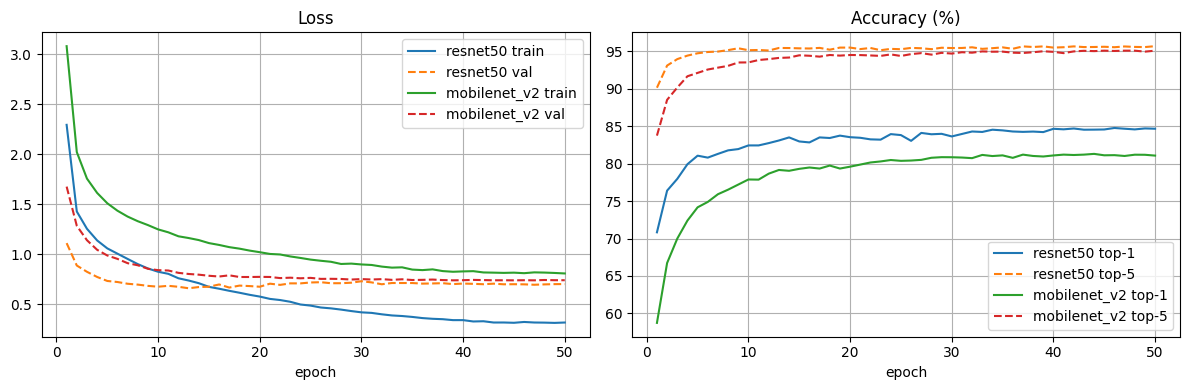

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in ['resnet50', 'mobilenet_v2']:
    csv_path = f'{OUTPUT_DIR}/{model_name}/training_log.csv'
    if not os.path.exists(csv_path):
        continue
    df = pd.read_csv(csv_path)
    axes[0].plot(df['epoch'], df['train_loss'], label=f'{model_name} train')
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{model_name} val', linestyle='--')
    axes[1].plot(df['epoch'], df['val_top1'] * 100, label=f'{model_name} top-1')
    axes[1].plot(df['epoch'], df['val_top5'] * 100, label=f'{model_name} top-5', linestyle='--')
    print(f'{model_name}: best val top-1 = {df["val_top1"].max()*100:.2f}%')

axes[0].set_title('Loss');     axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()